Dataset sources:

  English: https://www.kaggle.com/datasets/ashish2001/iam-dataset-modified

  Arabic: https://www.kaggle.com/datasets/iraqyomar/khatt-arabic-hand-written-lines

  Chinese: 

In [158]:
!pip install kagglehub

In [159]:
import kagglehub
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [160]:
plt.rcParams["font.family"] = "Arial Unicode MS"
random.seed(42)

In [161]:
ENGLISH_PATH = kagglehub.dataset_download("ashish2001/iam-dataset-modified")
ARABIC_PATH = kagglehub.dataset_download("iraqyomar/khatt-arabic-hand-written-lines")

In [162]:
class Line:
    def __init__(self, img_path, transcription):
        self.img_path = img_path
        self.transcription = transcription
        self.processed_img = None
        self.spacing = None
        self.spacing_annotated_img = None
        self.baseline_positions = None
        self.baseline_annotated_img = None

    def __repr__(self):
        return f"{self.img_path}: {self.transcription}"

In [163]:
ENGLISH_IMG_DIR = f"{ENGLISH_PATH}/upload/val"
ENGLISH_TRANSCRIPTION_FILE = f"{ENGLISH_PATH}/upload/val_list.txt"

ENGLISH_LINES = []

with open(ENGLISH_TRANSCRIPTION_FILE, "r") as f:
    for line in f:
        line_list = line.split("	")
        img_path = line_list[0].split("/")[-1]
        transcription = line_list[1].strip()
        for mark in ",.!?;:)}]-/\'":
            transcription = transcription.replace(" " + mark, mark)
        for mark in "({[-/\'":
            transcription = transcription.replace(mark + " ", mark)
        if " " not in transcription:
            continue
        ENGLISH_LINES.append(Line(img_path, transcription))

print(len(ENGLISH_LINES))



662


In [164]:
REMOVE_ARABIC_SPACES = True

ARABIC_IMG_DIR = f"{ARABIC_PATH}/images"
ARABIC_LABEL_DIR = f"{ARABIC_PATH}/labels"

ARABIC_ALL_LINES = os.listdir(ARABIC_LABEL_DIR)
ARABIC_SUBSET_LINES = random.sample(ARABIC_ALL_LINES, 1000)

ARABIC_LINES = []

for line in ARABIC_SUBSET_LINES:
    with open(os.path.join(ARABIC_LABEL_DIR, line), "r", encoding="cp1256") as f:
        transcription = f.read()
        transcription = " ".join(transcription.split())
        if " " not in transcription:
            continue
        transcription = transcription[::-1]
        if REMOVE_ARABIC_SPACES:
            transcription = transcription.replace(" ", "")
        img_path = line.replace(".txt", ".jpg")
        ARABIC_LINES.append(Line(img_path, transcription))

print(len(ARABIC_LINES))



997


In [165]:
def display_sample_images(lines, img_dir):
    fig, axes = plt.subplots(5, 1, figsize=(10, 10))

    for i, line in enumerate(lines[:5]):
        ax = axes[i]
        ax.axis("off")

        img_path = os.path.join(img_dir, line.img_path)
        img = Image.open(img_path)

        ax.imshow(img, cmap="gray")
        ax.set_title(line.transcription)
    plt.tight_layout()
    plt.show()

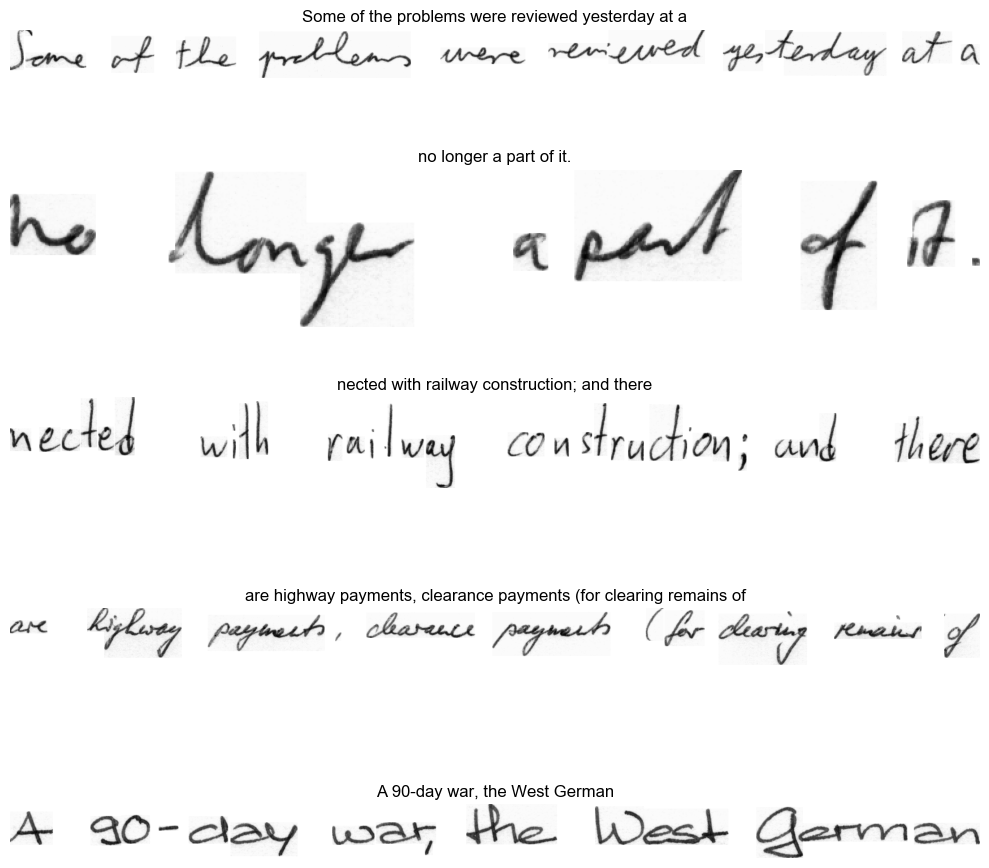

In [166]:
display_sample_images(ENGLISH_LINES, ENGLISH_IMG_DIR)

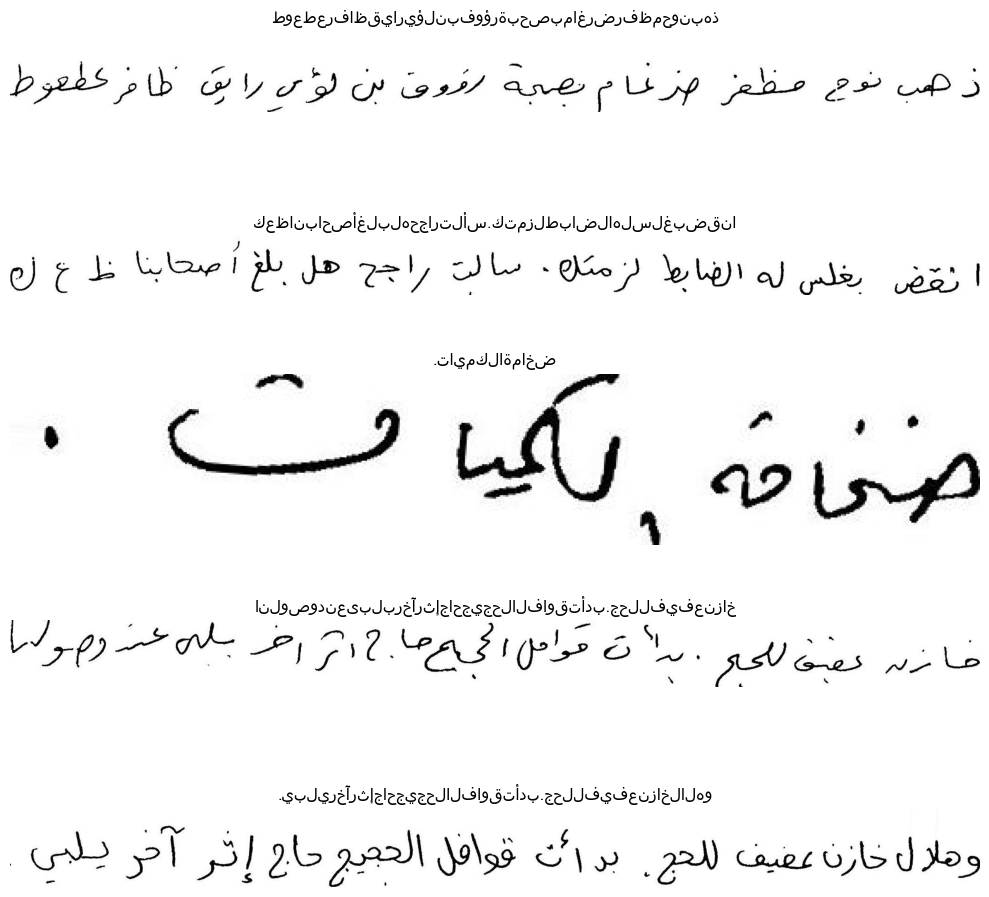

In [167]:
display_sample_images(ARABIC_LINES, ARABIC_IMG_DIR)

In [168]:
def process_line_img(img_path, output_height, threshold):
    img = Image.open(img_path).convert("L")
    arr = np.array(img)

    binary = (arr < threshold).astype(np.uint8)

    h, w = binary.shape

    scale = output_height / h

    new_h = output_height
    new_w = max(1, round(w * scale))

    binary_img = Image.fromarray((binary * 255).astype(np.uint8))
    resized_img = binary_img.resize((new_w, new_h), Image.NEAREST)
    resized = (np.array(resized_img) > 0).astype(np.uint8)

    return resized

In [169]:
def process_language(lines, img_dir, output_height, threshold):
    for line in lines:
        img_path = os.path.join(img_dir, line.img_path)
        processed_img = process_line_img(img_path, output_height, threshold)
        line.processed_img = processed_img

def display_sample_processed_images(lines):
    fig, axes = plt.subplots(5, 1, figsize=(10, 5))

    for i, line in enumerate(lines[:5]):
        img = line.processed_img

        ax = axes[i]
        ax.axis("off")
        ax.imshow(img, cmap="gray")
        ax.set_title(line.transcription, fontsize=8)

    plt.subplots_adjust(hspace=0.8)
    plt.show()


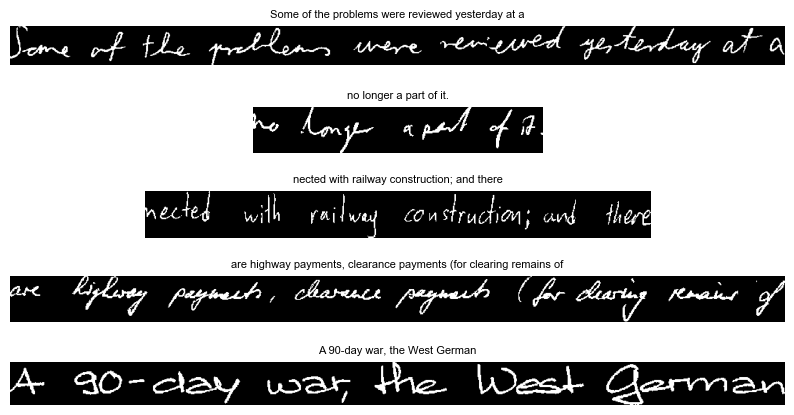

In [170]:
process_language(ENGLISH_LINES, ENGLISH_IMG_DIR, output_height=60, threshold=180)
display_sample_processed_images(ENGLISH_LINES)

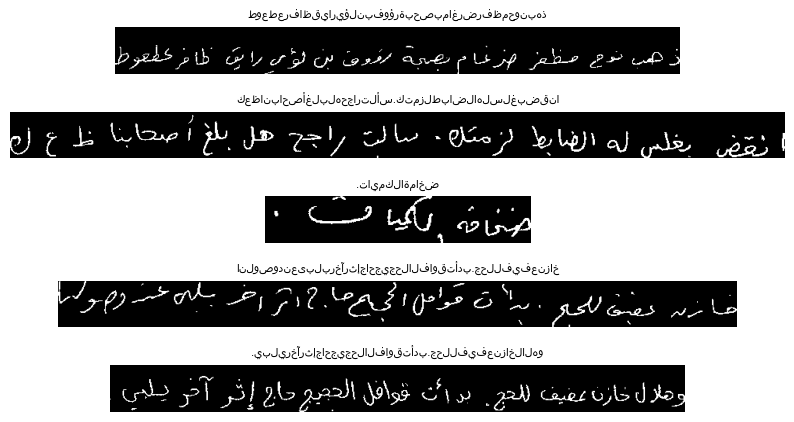

In [171]:
process_language(ARABIC_LINES, ARABIC_IMG_DIR, output_height=60, threshold=180)
display_sample_processed_images(ARABIC_LINES)

In [172]:
def calculate_spacing(line, no_spaces=False):

    if no_spaces:
        num_chars = len(line.transcription)
        line.spacing = [line.processed_img.shape[1] / num_chars] * num_chars
        return [-1], line.spacing
    
    img = line.processed_img
    column_sums = np.sum(img, axis=0)

    blank_columns = column_sums == 0

    gap_widths = []
    current_gap = 0
    gap_start = None

    for i, is_blank in enumerate(blank_columns):
        if is_blank:
            if current_gap == 0:
                gap_start = i
            current_gap += 1
        else:
            if current_gap > 0:
                gap_widths.append((gap_start, current_gap))
                current_gap = 0
                gap_start = None

    num_spaces = line.transcription.count(" ")

    if len(gap_widths) < num_spaces:
        return -1, -1
        

    largest_gap_indices = sorted(
        range(len(gap_widths)),
        key=lambda i: gap_widths[i][1],
        reverse=True
    )

    space_indices = largest_gap_indices[:num_spaces]
    space_indices = sorted(space_indices)

    space_gaps = [gap_widths[i] for i in space_indices]

    spacing = []
    space_idx = 0

    character_widths = []

    for word in line.transcription.split(" "):
        if space_idx == 0:
            word_width = space_gaps[0][0]
        elif space_idx == len(space_gaps):
            word_width = img.shape[1] - (space_gaps[-1][0] + space_gaps[-1][1])
        else:
            word_width = space_gaps[space_idx][0] - (space_gaps[space_idx - 1][0] + space_gaps[space_idx - 1][1])
        avg_char_width = word_width / len(word)
        for i in range(len(word)):
            spacing.append(avg_char_width)
            character_widths.append(avg_char_width)
        if space_idx != len(space_gaps):
            spacing.append(space_gaps[space_idx][1])
        space_idx += 1

    line.spacing = spacing

    space_widths = [gap[1] for gap in space_gaps]
    return space_widths, character_widths
    
def calculate_spacing_stats(lines, no_spaces=False):
    intraline_space_width_coefficients_of_variation = []
    intraline_character_width_coefficients_of_variation = []
    all_space_widths = []
    all_character_widths = []
    valid_lines = []

    for line in lines:
        space_widths, character_widths = calculate_spacing(line, no_spaces=no_spaces)

        if space_widths == -1:
            continue

        valid_lines.append(line)

        all_space_widths.extend(space_widths)
        all_character_widths.extend(character_widths)

        avg_space_widths = np.mean(space_widths)
        std_space_widths = np.std(space_widths)
        intraline_space_width_coefficients_of_variation.append(std_space_widths/avg_space_widths)

        avg_character_widths = np.mean(character_widths)
        std_character_widths = np.std(character_widths)
        intraline_character_width_coefficients_of_variation.append(std_character_widths/avg_character_widths)


    avg_interline_space_width_coefficient_of_variation = np.std(all_space_widths)/np.mean(all_space_widths)
    avg_interline_character_width_coefficient_of_variation = np.std(all_character_widths)/np.mean(all_character_widths)
    avg_intraline_space_width_coefficient_of_variation = np.mean(intraline_space_width_coefficients_of_variation)
    avg_intraline_character_width_coefficient_of_variation = np.mean(intraline_character_width_coefficients_of_variation)

    
    return avg_interline_space_width_coefficient_of_variation, avg_interline_character_width_coefficient_of_variation, \
        avg_intraline_space_width_coefficient_of_variation, avg_intraline_character_width_coefficient_of_variation, valid_lines

In [173]:
english_avg_interline_space_width_coefficient_of_variation, \
    english_avg_interline_character_width_coefficient_of_variation, \
    english_avg_intraline_space_width_coefficient_of_variation, \
    english_avg_intraline_character_width_coefficient_of_variation, \
    english_valid_lines= calculate_spacing_stats(ENGLISH_LINES)
ENGLISH_LINES = english_valid_lines
print(f"English Average Interline Space Width Coefficient of Variation: {english_avg_interline_space_width_coefficient_of_variation}")
print(f"English Average Interline Character Width Coefficient of Variation: {english_avg_interline_character_width_coefficient_of_variation}")
print(f"English Average Intraline Space Width Coefficient of Variation: {english_avg_intraline_space_width_coefficient_of_variation}")
print(f"English Average Intraline Character Width Coefficient of Variation: {english_avg_intraline_character_width_coefficient_of_variation}")

English Average Interline Space Width Coefficient of Variation: 0.5092664858835431
English Average Interline Character Width Coefficient of Variation: 0.6387193843717024
English Average Intraline Space Width Coefficient of Variation: 0.2492703237849461
English Average Intraline Character Width Coefficient of Variation: 0.2887697879476144


In [174]:
arabic_avg_interline_space_width_coefficient_of_variation, \
    arabic_avg_interline_character_width_coefficient_of_variation, \
    arabic_avg_intraline_space_width_coefficient_of_variation, \
    arabic_avg_intraline_character_width_coefficient_of_variation, \
    arabic_valid_lines= calculate_spacing_stats(ARABIC_LINES, no_spaces=REMOVE_ARABIC_SPACES)
ARABIC_LINES = arabic_valid_lines
print(f"Arabic Average Interline Space Width Coefficient of Variation: {arabic_avg_interline_space_width_coefficient_of_variation}")
print(f"Arabic Average Interline Character Width Coefficient of Variation: {arabic_avg_interline_character_width_coefficient_of_variation}")
print(f"Arabic Average Intraline Space Width Coefficient of Variation: {arabic_avg_intraline_space_width_coefficient_of_variation}")
print(f"Arabic Average Intraline Character Width Coefficient of Variation: {arabic_avg_intraline_character_width_coefficient_of_variation}")

Arabic Average Interline Space Width Coefficient of Variation: -0.0
Arabic Average Interline Character Width Coefficient of Variation: 0.28271976676879723
Arabic Average Intraline Space Width Coefficient of Variation: 0.0
Arabic Average Intraline Character Width Coefficient of Variation: 1.261642184608027e-16


In [175]:
def spacing_annotate_line(line):
    img = line.processed_img
    h, w = img.shape

    num_chars = len(line.transcription)

    annotated = np.stack([img * 255] * 3, axis=-1).astype(np.uint8)

    cursor = 0

    for i in range(0, num_chars):
        cursor += line.spacing[i]

        x = round(cursor)

        if 0 <= x < w:
            annotated[:, x, 0] = 255
            annotated[:, x, 1] = 0
            annotated[:, x, 2] = 0

    line.spacing_annotated_img = annotated

def create_spacing_annotated_images(lines):
    for line in lines:
        spacing_annotate_line(line)

def display_sample_spacing_annotated_images(lines):
    fig, axes = plt.subplots(5, 1, figsize=(10, 5))

    for i, line in enumerate(lines[:5]):
        img = line.spacing_annotated_img

        ax = axes[i]
        ax.axis("off")
        ax.imshow(img)
        ax.set_title(line.transcription, fontsize=8)

    plt.subplots_adjust(hspace=0.8)
    plt.show()


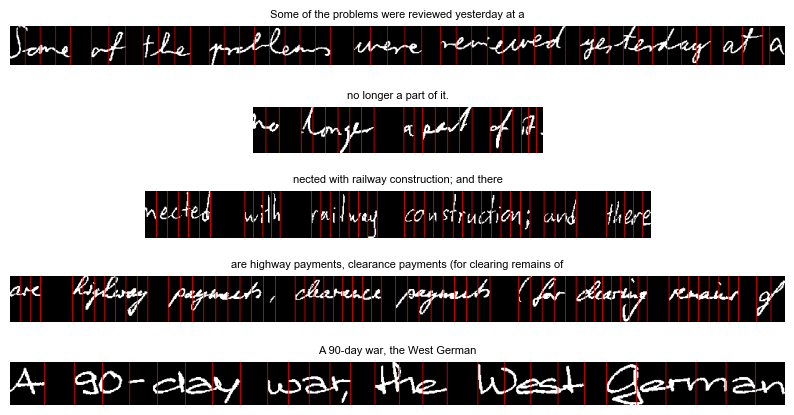

In [176]:
create_spacing_annotated_images(ENGLISH_LINES)
display_sample_spacing_annotated_images(ENGLISH_LINES)

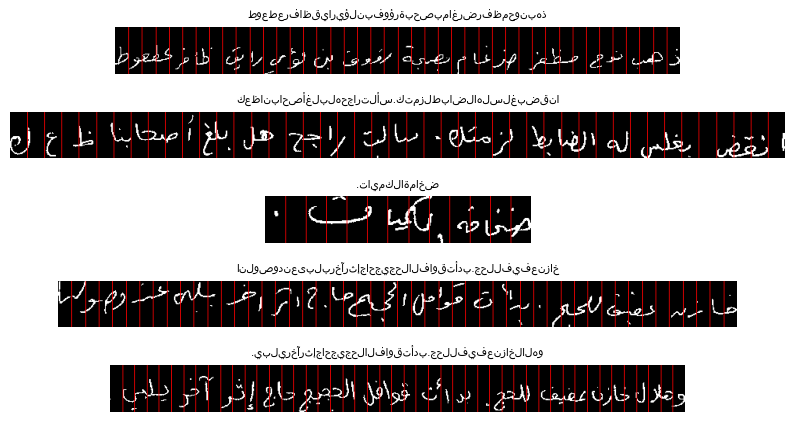

In [177]:
create_spacing_annotated_images(ARABIC_LINES)
display_sample_spacing_annotated_images(ARABIC_LINES)

In [178]:
def calculate_baseline(line, ignore_chars="", ignore_whole_word=False):
    img = line.processed_img
    h, w = img.shape

    baseline_positions = []
    cursor = 0

    words = line.transcription.split(" ")
    word_idx = 0

    for i, char in enumerate(line.transcription):
        char_width = line.spacing[i]

        x_start = round(cursor)
        x_end = round(cursor + char_width)

        cursor += char_width

        if char == " ":
            baseline_positions.append(-1)
            word_idx += 1
            continue

        if char in ignore_chars:
            baseline_positions.append(-1)
            continue

        if ignore_whole_word:
            continuing = False
            for c in words[word_idx]:
                if c in ignore_chars:
                    baseline_positions.append(-1)
                    continuing = True
                    break
            if continuing:
                continue

        char_region = img[:, x_start:x_end]

        coords = np.argwhere(char_region == 1)

        if len(coords) == 0:
            return -1

        lowest_pixel = coords[:, 0].max()

        baseline_positions.append(lowest_pixel)

    line.baseline_positions = baseline_positions
    
    valid_baseline_positions = [pos for pos in baseline_positions if pos != -1]
    return np.std(valid_baseline_positions) / h


def calculate_baseline_stats(lines, ignore_chars="", ignore_whole_word=True):
    intraline_baseline_stds = []
    valid_lines = []

    for line in lines:
        baseline_std = calculate_baseline(line, ignore_chars=ignore_chars, ignore_whole_word=ignore_whole_word)
        if baseline_std == -1:
            continue
        valid_lines.append(line)
        intraline_baseline_stds.append(baseline_std)


    return np.mean(intraline_baseline_stds), valid_lines

In [179]:
english_avg_intraline_baseline_std, english_valid_lines = calculate_baseline_stats(ENGLISH_LINES)
ENGLISH_LINES = english_valid_lines
print(f"English Average Intraline Baseline Std Dev: {english_avg_intraline_baseline_std}")

English Average Intraline Baseline Std Dev: 0.1048666351078227


In [180]:
arabic_avg_intraline_baseline_std, arabic_valid_lines = calculate_baseline_stats(ARABIC_LINES)
ARABIC_LINES = arabic_valid_lines
print(f"Arabic Average Intraline Baseline Std Dev: {arabic_avg_intraline_baseline_std}")

Arabic Average Intraline Baseline Std Dev: 0.12451193203682445


In [181]:
def baseline_annotate_line(line):
    img = line.processed_img
    h, w = img.shape

    annotated = line.spacing_annotated_img.copy()

    cursor = 0
    baseline_idx = 0

    for i, char in enumerate(line.transcription):
        char_width = line.spacing[i]

        x_start = round(cursor)
        x_end = round(cursor + char_width)

        cursor += char_width

        baseline_y = line.baseline_positions[baseline_idx]
        baseline_idx += 1

        if baseline_y == -1:
            continue

        x_start = max(0, x_start)
        x_end = min(w, x_end)

        if x_end <= x_start:
            continue

        if 0 <= baseline_y < h:
            annotated[baseline_y, x_start:x_end, 0] = 0
            annotated[baseline_y, x_start:x_end, 1] = 255
            annotated[baseline_y, x_start:x_end, 2] = 0

    line.baseline_annotated_img = annotated

def create_baseline_annotated_images(lines):
    for line in lines:
        baseline_annotate_line(line)

def display_sample_baseline_annotated_images(lines):
    fig, axes = plt.subplots(5, 1, figsize=(10, 5))

    for i, line in enumerate(lines[:5]):
        img = line.baseline_annotated_img

        ax = axes[i]
        ax.axis("off")
        ax.imshow(img)
        ax.set_title(line.transcription, fontsize=8)

    plt.subplots_adjust(hspace=0.8)
    plt.show()

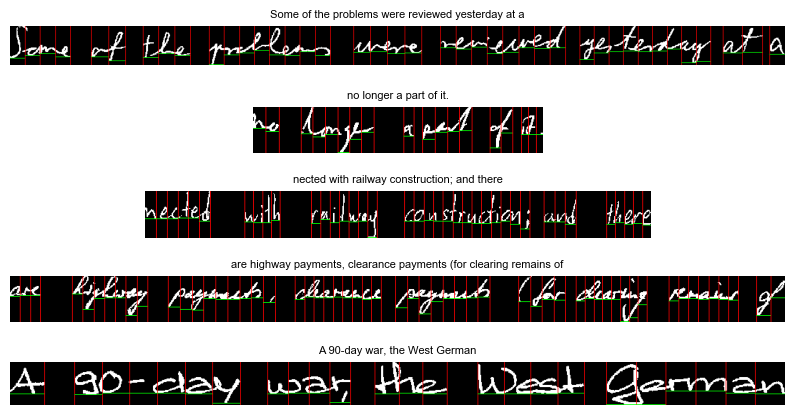

In [182]:
create_baseline_annotated_images(ENGLISH_LINES)
display_sample_baseline_annotated_images(ENGLISH_LINES)

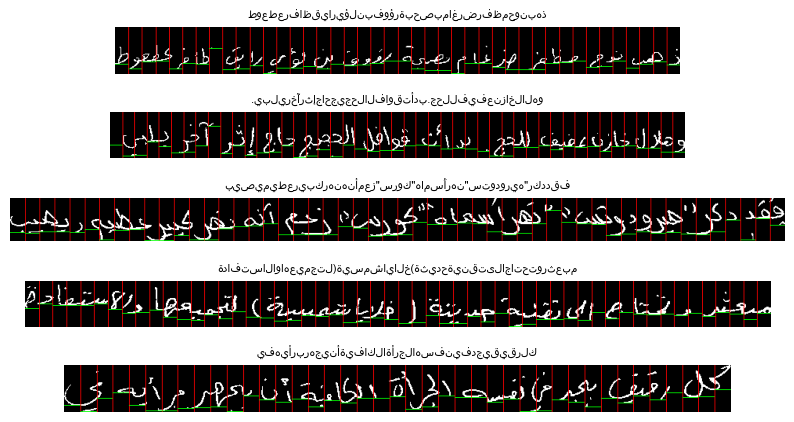

In [183]:
create_baseline_annotated_images(ARABIC_LINES)
display_sample_baseline_annotated_images(ARABIC_LINES)

English Average Intraline Baseline Std Dev: 0.05965880324782919


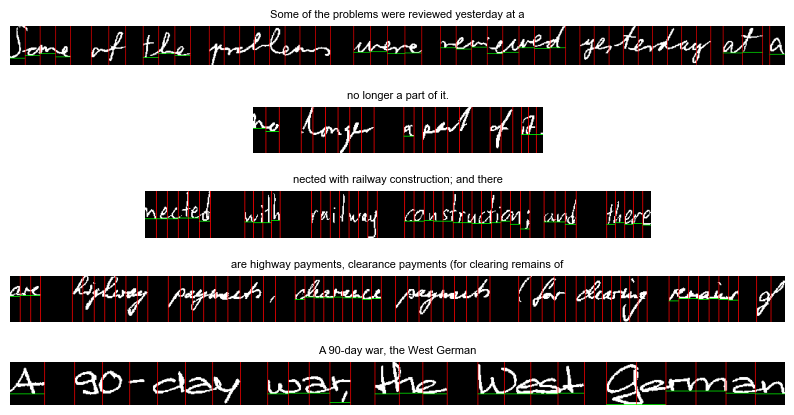

In [184]:
ENGLISH_IGNORE_CHARS = "fgjpqy"

english_avg_intraline_baseline_std, english_valid_lines = calculate_baseline_stats(ENGLISH_LINES, ignore_chars=ENGLISH_IGNORE_CHARS, ignore_whole_word=True)
ENGLISH_LINES = english_valid_lines
print(f"English Average Intraline Baseline Std Dev: {english_avg_intraline_baseline_std}")

create_baseline_annotated_images(ENGLISH_LINES)
display_sample_baseline_annotated_images(ENGLISH_LINES)